# Day 5: Quantitative Models & Portfolio Optimization

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

processed_dir = Path("../data/processed")
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

nav = pd.read_csv(processed_dir / "clean_nav.csv")
fm = pd.read_csv(processed_dir / "clean_fund_master.csv")
nav['date'] = pd.to_datetime(nav['date'])

## 1. Monte Carlo Simulation Setup

In [2]:
sbi_small_cap_code = 119551
fund_nav = nav[nav['amfi_code'] == sbi_small_cap_code].sort_values('date').copy()
fund_nav['daily_return'] = fund_nav['nav'].pct_change()

returns = fund_nav['daily_return'].dropna()
drift = returns.mean()
volatility = returns.std()
latest_nav = fund_nav.iloc[-1]['nav']

print(f"Latest actual NAV: INR {latest_nav:.2f}")
print(f"Calculated Daily Return Drift (Mean): {drift:.5%}")
print(f"Calculated Daily Volatility (StDev): {volatility:.5%}")

Latest actual NAV: INR 149.32
Calculated Daily Return Drift (Mean): 0.06555%
Calculated Daily Volatility (StDev): 0.73303%


## 2. Generating Simulated Pricing Paths

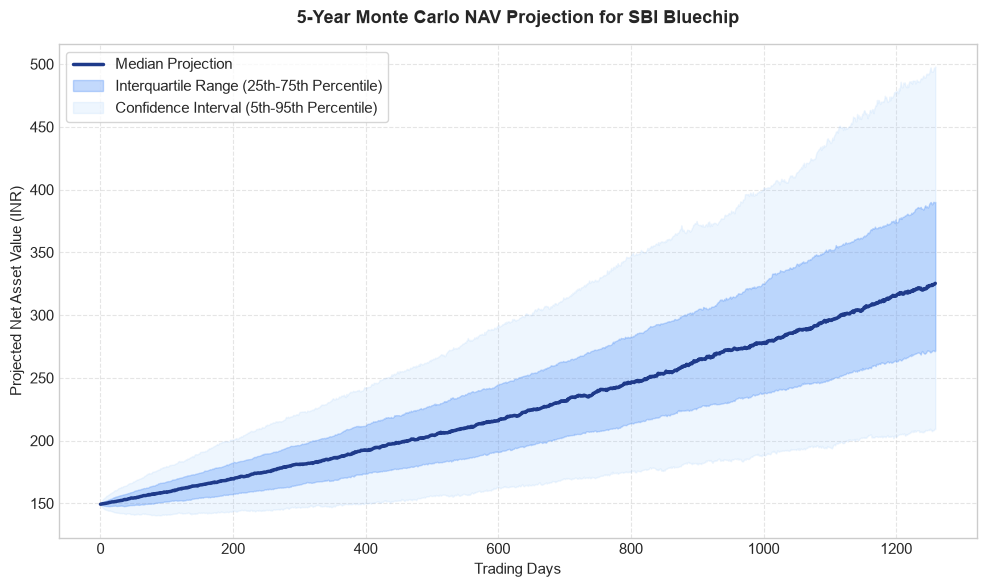

In [3]:
n_days = 1260
n_simulations = 1000
sim_nav = np.zeros((n_days, n_simulations))
sim_nav[0, :] = latest_nav

# Generate simulations
np.random.seed(42)
for t in range(1, n_days):
    shocks = np.random.normal(drift, volatility, n_simulations)
    sim_nav[t, :] = sim_nav[t-1, :] * (1 + shocks)

p5 = np.percentile(sim_nav, 5, axis=1)
p25 = np.percentile(sim_nav, 25, axis=1)
p50 = np.percentile(sim_nav, 50, axis=1)
p75 = np.percentile(sim_nav, 75, axis=1)
p95 = np.percentile(sim_nav, 95, axis=1)

# Plotting simulation results
plt.figure(figsize=(10, 6))
plt.plot(p50, label='Median Projection', color='#1e3a8a', linewidth=2.5)
plt.fill_between(range(n_days), p25, p75, color='#3b82f6', alpha=0.3, label='Interquartile Range (25th-75th Percentile)')
plt.fill_between(range(n_days), p5, p95, color='#93c5fd', alpha=0.15, label='Confidence Interval (5th-95th Percentile)')

plt.title("5-Year Monte Carlo NAV Projection for SBI Bluechip", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Trading Days")
plt.ylabel("Projected Net Asset Value (INR)")
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(reports_dir / "monte_carlo_simulation.png", dpi=150)
plt.show()

## 3. Markowitz Efficient Frontier Setup

In [4]:
selected_codes = [119551, 120503, 118632, 119092, 120841]
portfolio_nav = nav[nav['amfi_code'].isin(selected_codes)].pivot(index='date', columns='amfi_code', values='nav')
portfolio_returns = portfolio_nav.pct_change().dropna()

name_mapping = fm.set_index('amfi_code')['scheme_name'].to_dict()
portfolio_returns = portfolio_returns.rename(columns=name_mapping)

mean_returns = portfolio_returns.mean() * 252
cov_matrix = portfolio_returns.cov() * 252

print("Annualized Return for selected funds:")
for name, val in mean_returns.items():
    print(f" - {name}: {val:.2%}")

Annualized Return for selected funds:
 - Nippon India Large Cap Fund - Regular - Growth: 15.59%
 - Axis Bluechip Fund - Regular - Growth: 4.95%
 - SBI Bluechip Fund - Regular Plan - Growth: 16.52%
 - ICICI Pru Bluechip Fund - Regular - Growth: 12.57%
 - Kotak Bluechip Fund - Regular - Growth: 9.41%


## 4. Run Portfolio Simulations

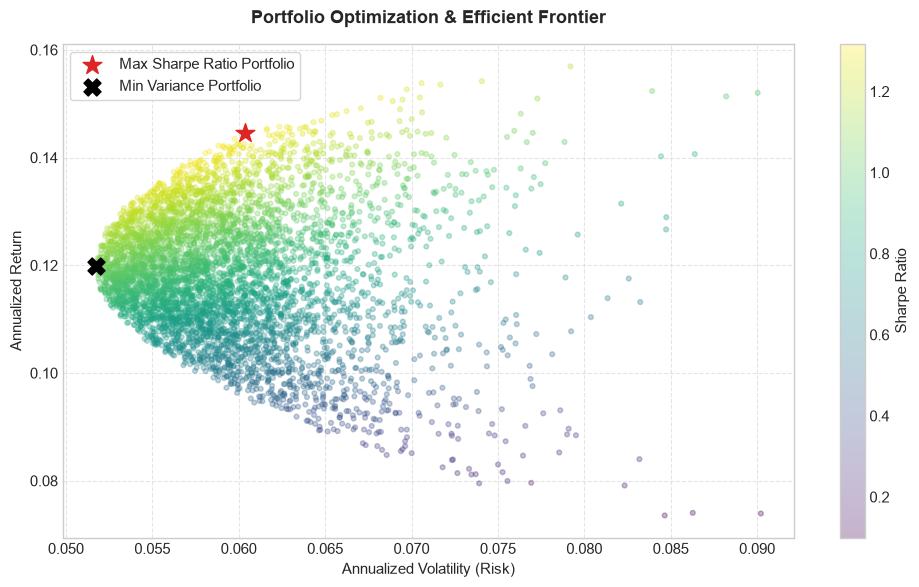

In [5]:
n_portfolios = 5000
results = np.zeros((3, n_portfolios))
weights_record = []
rf = 0.065

np.random.seed(42)
for i in range(n_portfolios):
    weights = np.random.random(len(selected_codes))
    weights /= np.sum(weights)
    weights_record.append(weights)
    p_return = np.sum(mean_returns * weights)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    p_sharpe = (p_return - rf) / p_volatility
    results[0, i] = p_return
    results[1, i] = p_volatility
    results[2, i] = p_sharpe

# Find key portfolios
max_sharpe_idx = np.argmax(results[2])
msr_ret, msr_vol = results[0, max_sharpe_idx], results[1, max_sharpe_idx]
msr_weights = weights_record[max_sharpe_idx]

min_vol_idx = np.argmin(results[1])
mvp_ret, mvp_vol = results[0, min_vol_idx], results[1, min_vol_idx]
mvp_weights = weights_record[min_vol_idx]

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', marker='o', s=12, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(msr_vol, msr_ret, marker='*', color='#dc2626', s=200, label='Max Sharpe Ratio Portfolio')
plt.scatter(mvp_vol, mvp_ret, marker='X', color='black', s=150, label='Min Variance Portfolio')

plt.title("Portfolio Optimization & Efficient Frontier", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(reports_dir / "efficient_frontier.png", dpi=150)
plt.show()

## 5. Optimal Allocation Results

In [6]:
print("=== Maximum Sharpe Ratio Portfolio ===")
print(f"Annualized Return: {msr_ret:.2%}")
print(f"Annualized Volatility: {msr_vol:.2%}")
print(f"Sharpe Ratio: {results[2, max_sharpe_idx]:.3f}")
for name, w in zip(portfolio_returns.columns, msr_weights):
    print(f" - {name}: {w:.2%}")

print("\n=== Minimum Variance Portfolio ===")
print(f"Annualized Return: {mvp_ret:.2%}")
print(f"Annualized Volatility: {mvp_vol:.2%}")
print(f"Sharpe Ratio: {results[2, min_vol_idx]:.3f}")
for name, w in zip(portfolio_returns.columns, mvp_weights):
    print(f" - {name}: {w:.2%}")

=== Maximum Sharpe Ratio Portfolio ===
Annualized Return: 14.45%
Annualized Volatility: 6.04%
Sharpe Ratio: 1.317
 - Nippon India Large Cap Fund - Regular - Growth: 30.92%
 - Axis Bluechip Fund - Regular - Growth: 0.36%
 - SBI Bluechip Fund - Regular Plan - Growth: 34.14%
 - ICICI Pru Bluechip Fund - Regular - Growth: 22.86%
 - Kotak Bluechip Fund - Regular - Growth: 11.72%

=== Minimum Variance Portfolio ===
Annualized Return: 11.99%
Annualized Volatility: 5.17%
Sharpe Ratio: 1.062
 - Nippon India Large Cap Fund - Regular - Growth: 19.06%
 - Axis Bluechip Fund - Regular - Growth: 18.39%
 - SBI Bluechip Fund - Regular Plan - Growth: 23.10%
 - ICICI Pru Bluechip Fund - Regular - Growth: 18.49%
 - Kotak Bluechip Fund - Regular - Growth: 20.97%
